# PR5 — Classification Threshold

## Цель работы

Обучить модель бинарной классификации, получить вероятности классов,
построить ROC- и PR-кривые, подобрать порог классификации с учётом
цены ошибок и сравнить качество модели при стандартном и выбранном порогах.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

In [7]:
df = pd.read_csv("../data/brca.csv")

df.head()

,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


In [9]:
df.shape

(569, 32)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           569 non-null    int64  
 1   x.radius_mean        569 non-null    float64
 2   x.texture_mean       569 non-null    float64
 3   x.perimeter_mean     569 non-null    float64
 4   x.area_mean          569 non-null    float64
 5   x.smoothness_mean    569 non-null    float64
 6   x.compactness_mean   569 non-null    float64
 7   x.concavity_mean     569 non-null    float64
 8   x.concave_pts_mean   569 non-null    float64
 9   x.symmetry_mean      569 non-null    float64
 10  x.fractal_dim_mean   569 non-null    float64
 11  x.radius_se          569 non-null    float64
 12  x.texture_se         569 non-null    float64
 13  x.perimeter_se       569 non-null    float64
 14  x.area_se            569 non-null    float64
 15  x.smoothness_se      569 non-null    float64
 16  x

In [11]:
# Шаг 5. Определяем target

X = df.drop(columns=["y", "Unnamed: 0"])
y = df["y"]

print(y.value_counts())

y
B    357
M    212
Name: count, dtype: int64


In [12]:
y = y.map({
    "B": 0,
    "M": 1
})

In [13]:
y.value_counts()

y
0    357
1    212
Name: count, dtype: int64

In [14]:
y.value_counts(normalize=True)

y
0    0.627417
1    0.372583
Name: proportion, dtype: float64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


In [17]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

print("Числовые признаки:")
print(numeric_features)

print("\nКатегориальные признаки:")
print(categorical_features)

Числовые признаки:
Index(['x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean',
       'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean',
       'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean',
       'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se',
       'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst'],
      dtype='str')

Категориальные признаки:
Index([], dtype='str')


In [18]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [19]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [20]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['x.radius_mean','x.texture_mean','x.perimeter_mean',..., 'x.concave_pts_worst','x.symmetry_worst','x.fractal_dim_worst']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'d

In [21]:
y_proba = model.predict_proba(X_test)[:, 1]

In [22]:
y_proba[:10]

array([3.64568116e-04, 9.99999989e-01, 4.25679471e-02, 5.76187322e-01,
       5.09155489e-01, 6.16001620e-04, 7.61534086e-01, 1.01217174e-03,
       5.68725516e-04, 1.07675795e-02])

In [23]:
y_pred_05 = (y_proba >= 0.5).astype(int)

In [24]:
accuracy_05 = accuracy_score(y_test, y_pred_05)
precision_05 = precision_score(y_test, y_pred_05)
recall_05 = recall_score(y_test, y_pred_05)
f1_05 = f1_score(y_test, y_pred_05)

print("Threshold = 0.5")
print(f"Accuracy:  {accuracy_05:.3f}")
print(f"Precision: {precision_05:.3f}")
print(f"Recall:    {recall_05:.3f}")
print(f"F1:        {f1_05:.3f}")

Threshold = 0.5
Accuracy:  0.965
Precision: 0.975
Recall:    0.929
F1:        0.951


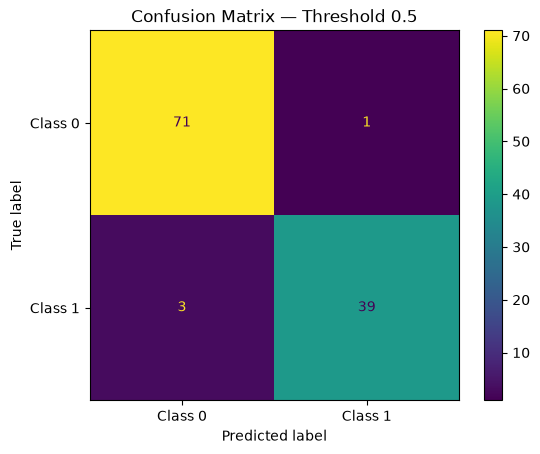

In [25]:
cm = confusion_matrix(y_test, y_pred_05)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()
plt.title("Confusion Matrix — Threshold 0.5")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

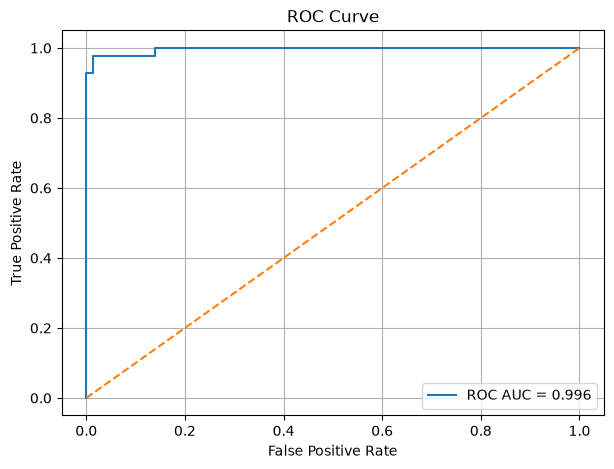

In [26]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)

roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [27]:
print(f"ROC AUC: {roc_auc:.3f}")

ROC AUC: 0.996


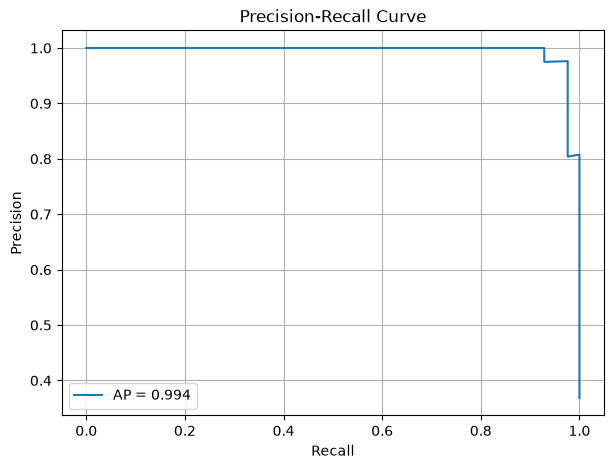

In [28]:
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_proba
)

pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AP = {pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

In [29]:
print(f"Average Precision: {pr_auc:.3f}")

Average Precision: 0.994


In [30]:
thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "FP": fp,
        "FN": fn
    })

results_df = pd.DataFrame(results)

results_df

,threshold,accuracy,precision,recall,f1,FP,FN
0,0.10,0.947368,0.891304,0.976190,0.931818,5,1
1,0.15,0.956140,0.911111,0.976190,0.942529,4,1
2,0.20,0.956140,0.911111,0.976190,0.942529,4,1
3,0.25,0.982456,0.976190,0.976190,0.976190,1,1
4,0.30,0.982456,0.976190,0.976190,0.976190,1,1
5,0.35,0.973684,0.975610,0.952381,0.963855,1,2
6,0.40,0.973684,0.975610,0.952381,0.963855,1,2
7,0.45,0.973684,0.975610,0.952381,0.963855,1,2
8,0.50,0.964912,0.975000,0.928571,0.951220,1,3
9,0.55,0.973684,1.000000,0.928571,0.962963,0,3


In [31]:
FP_COST = 1
FN_COST = 5

In [32]:
results_df["cost"] = (
    results_df["FP"] * FP_COST +
    results_df["FN"] * FN_COST
)

results_df

,threshold,accuracy,precision,recall,f1,FP,FN,cost
0,0.10,0.947368,0.891304,0.976190,0.931818,5,1,10
1,0.15,0.956140,0.911111,0.976190,0.942529,4,1,9
2,0.20,0.956140,0.911111,0.976190,0.942529,4,1,9
3,0.25,0.982456,0.976190,0.976190,0.976190,1,1,6
4,0.30,0.982456,0.976190,0.976190,0.976190,1,1,6
5,0.35,0.973684,0.975610,0.952381,0.963855,1,2,11
6,0.40,0.973684,0.975610,0.952381,0.963855,1,2,11
7,0.45,0.973684,0.975610,0.952381,0.963855,1,2,11
8,0.50,0.964912,0.975000,0.928571,0.951220,1,3,16
9,0.55,0.973684,1.000000,0.928571,0.962963,0,3,15


In [33]:
best_row = results_df.loc[results_df["cost"].idxmin()]

best_row

threshold    0.250000
accuracy     0.982456
precision    0.976190
recall       0.976190
f1           0.976190
FP           1.000000
FN           1.000000
cost         6.000000
Name: 3, dtype: float64

In [34]:
best_threshold = best_row["threshold"]

print(f"Best threshold: {best_threshold:.2f}")
print(f"Minimum cost: {best_row['cost']:.0f}")

Best threshold: 0.25
Minimum cost: 6


In [35]:
y_pred_best = (y_proba >= best_threshold).astype(int)

In [36]:
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)

print(f"Threshold = {best_threshold:.2f}")
print(f"Accuracy:  {accuracy_best:.3f}")
print(f"Precision: {precision_best:.3f}")
print(f"Recall:    {recall_best:.3f}")
print(f"F1:        {f1_best:.3f}")

Threshold = 0.25
Accuracy:  0.982
Precision: 0.976
Recall:    0.976
F1:        0.976


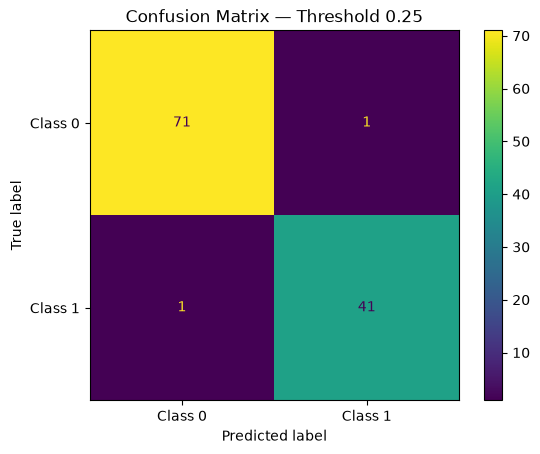

In [37]:
cm_best = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_best,
    display_labels=["Class 0", "Class 1"]
)

disp.plot()
plt.title(f"Confusion Matrix — Threshold {best_threshold:.2f}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [38]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Threshold 0.5": [
        accuracy_05,
        precision_05,
        recall_05,
        f1_05
    ],
    f"Threshold {best_threshold:.2f}": [
        accuracy_best,
        precision_best,
        recall_best,
        f1_best
    ]
})

comparison

,Metric,Threshold 0.5,Threshold 0.25
0,Accuracy,0.964912,0.982456
1,Precision,0.975000,0.976190
2,Recall,0.928571,0.976190
3,F1,0.951220,0.976190


## Обоснование выбора порога

В данной задаче цена ложноотрицательной ошибки (FN) выше цены
ложноположительной ошибки (FP): FN = 5, FP = 1.

Поэтому основной акцент был сделан на снижении количества FN и
увеличении Recall.

Были проверены различные пороги классификации от 0.1 до 0.9.
Для каждого порога была рассчитана общая стоимость ошибок:

Cost = FP × 1 + FN × 5.

Минимальная стоимость ошибок была получена при пороге [ВСТАВИТЬ ПОРОГ].

Поэтому данный порог был выбран вместо стандартного значения 0.5.

# Вывод

Была обучена модель Logistic Regression и получены вероятности
положительного класса с помощью predict_proba().

Качество ранжирования модели было оценено с помощью ROC-кривой,
ROC AUC и Precision-Recall кривой.

При стандартном пороге 0.5 модель показала:
	Metric	Threshold 0.5	
0	Accuracy	0.964912	
1	Precision	0.975000
2	Recall	0.928571	
3	F1	0.951220	

Поскольку стоимость ошибки FN выше стоимости FP, основной метрикой
для выбора порога был Recall, а также учитывалась общая стоимость ошибок.

После анализа нескольких порогов был выбран threshold = ...

При выбранном  Threshold 0.25: 
- Accuracy = 0.982456
- Precision = 0.976190
- Recall = 0.976190
- F1 = 0.976190

Изменение порога позволило уменьшить количество дорогостоящих
ложноотрицательных ошибок. Поэтому выбранный порог является более
подходящим для данной задачи, чем стандартный порог 0.5.